#**IMPORT**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# !wget --no-check-certificate -O "/content/drive/MyDrive/svamitva_project/data/raw/training/dataset.zip" "https://svamitva.nic.in/DownloadPDF/TifFile/PB_training_dataSet_shp_file.zip"
# !unzip "/content/drive/MyDrive/svamitva_project/data/raw/training/dataset.zip" -d "/content/drive/MyDrive/svamitva_project/data/raw/training"

In [ ]:
!pip install rasterio geopandas shapely

In [ ]:
!pip install torch torchvision

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
import os
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

import numpy as np
import random
from rasterio.windows import Window
from rasterio.features import rasterize


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch
import segmentation_models_pytorch as smp

In [ ]:
from shapely.geometry import box

In [ ]:
base = "/content/drive/MyDrive/svamitva_project/data/raw/training/chhatisgarh"

In [ ]:
print(os.listdir(base))

['MURDANDA_450879_AWAPALLI_CHINTAKONTA', 'NAGUL_450171_MADASE_450172_GHOTPAL_450137', 'SAMLUR_450163_SIYANAR_450164_KUTULNAR_450165_BINJAM_450166_JHODIYAWADAM_450167', 'BADETUMNAR_450157_BANGAPAL_450155_CHHOTETUMAR_450149_MOFALNAR_450150', 'KUTRU_451189_AAKLANKA_451163']


In [ ]:
folder = os.listdir(base)[0]
print("Selected village folder:", folder)

Selected village folder: MURDANDA_450879_AWAPALLI_CHINTAKONTA


In [ ]:
ori_path = os.path.join(base, folder, "ori")
print("ORI path:", ori_path)
print(os.listdir(ori_path))

ORI path: /content/drive/MyDrive/svamitva_project/data/raw/training/chhatisgarh/MURDANDA_450879_AWAPALLI_CHINTAKONTA/ori
['MURDANDA_450879_AWAPALLI_CHINTAKONTA_ORTHO.tif']


# **DATA ANALYSIS**

## Load Orthophoto Images

In [ ]:
tif_file = os.listdir(ori_path)[0]
img_path = os.path.join(ori_path, tif_file)
print("Orthophoto path:", img_path)

Orthophoto path: /content/drive/MyDrive/svamitva_project/data/raw/training/chhatisgarh/MURDANDA_450879_AWAPALLI_CHINTAKONTA/ori/MURDANDA_450879_AWAPALLI_CHINTAKONTA_ORTHO.tif


In [ ]:
with rasterio.open(img_path) as src:
    ortho_crs = src.crs
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bands:", src.count)

CRS: EPSG:32644
Width: 235404
Height: 119510
Bands: 4


Found valid patch at: 101203 106073


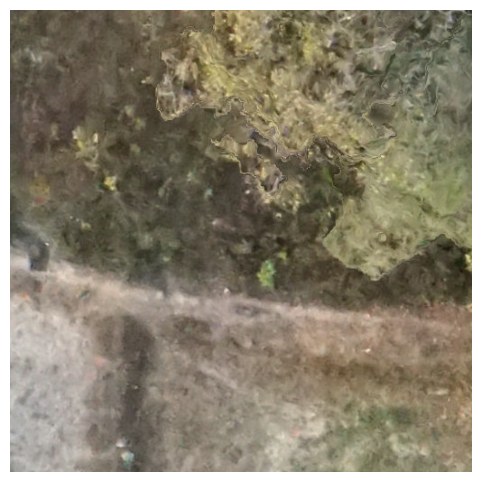

In [ ]:
with rasterio.open(img_path) as src:

    for _ in range(50):

        x = random.randint(0, src.width - 512)
        y = random.randint(0, src.height - 512)

        patch = src.read([1,2,3], window=Window(x, y, 512, 512))

        if patch.max() > 0:

            img = patch.transpose(1,2,0)

            img = img.astype(float)
            img = (img - img.min()) / (img.max() - img.min())

            plt.figure(figsize=(6,6))
            plt.imshow(img)
            plt.axis("off")
            print("Found valid patch at:", x, y)

            break

In [ ]:
shp_base = "/content/drive/MyDrive/svamitva_project/data/raw/training/shp_file"

## Load Shapefile Annotations

In [ ]:
builtup_path = os.path.join(os.path.join(shp_base, 'chhatisgarh'), "Built_Up_Area_type.shp")

gdf = gpd.read_file(builtup_path)

print("Total features:", len(gdf))

gdf.head()

Total features: 4790


,OBJECTID,GlobalID,Uniq_Id,State_Code,District_C,Tehsil_Cod,Block_Code,Village_Co,LGD_Code,Built_Up_A,...,Area_Sqm,Roof_type,No_Floors,Remarks,Adl_Info,SHAPE_Leng,SHAPE_Area,GP_Code,GP_Name,geometry
0,0,None,None,22,376,3370,3619,450157,450157,1,...,43.392683,1,0,None,None,43.392683,43.392683,123510,BADETUMNAR,"POLYGON ((9042844.974 2156696.947, 9042841.236..."
1,0,None,None,22,376,3370,3619,450157,450157,1,...,163.208124,1,1,None,None,163.208124,163.208124,123510,BADETUMNAR,"POLYGON ((9042837.59 2156687.225, 9042837.368 ..."
2,0,None,None,22,376,3370,3619,450157,450157,1,...,26.189821,3,2,None,None,26.189821,26.189821,123510,BADETUMNAR,"POLYGON ((9042837.258 2156702.768, 9042842.64 ..."
3,0,None,None,22,376,3370,3619,450157,450157,1,...,21.035735,4,0,None,None,21.035735,21.035735,123510,BADETUMNAR,"POLYGON ((9042821.366 2156698.841, 9042823.013..."
4,0,None,None,22,376,3370,3619,450157,450157,1,...,35.135629,3,0,None,None,35.135629,35.135629,123510,BADETUMNAR,"POLYGON ((9042860.484 2156718.43, 9042860.341 ..."


# **PRE-PROCESSING**

In [ ]:
if gdf.crs != src.crs:
    gdf = gdf.to_crs(src.crs)

In [ ]:
tile_size = 256
stride = 256

## Dataset Generation

In [ ]:
image_dir = "/content/drive/MyDrive/svamitva_project/data/processed/tiles"
mask_dir = "/content/drive/MyDrive/svamitva_project/data/processed/masks"

os.makedirs(image_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

In [ ]:
from shapely.geometry import box

def generate_tiles(img_path):

    tile_id = 0

    try:
        src = rasterio.open(img_path)
    except Exception as e:
        print("⚠️ Cannot open image:", img_path)
        print("Reason:", e)
        return

    with src:

        gdf_local = gdf.to_crs(src.crs)

        for y in range(0, src.height, stride):

            for x in range(0, src.width, stride):

                if x + tile_size > src.width or y + tile_size > src.height:
                    continue

                window = Window(x, y, tile_size, tile_size)

                image = src.read([1,2,3], window=window)

                if image.max() == 0:
                    continue

                transform = src.window_transform(window)

                bounds = rasterio.windows.bounds(window, src.transform)

                tile_box = box(bounds[0], bounds[1], bounds[2], bounds[3])

                bbox = gdf_local[gdf_local.intersects(tile_box)]

                if bbox.empty:
                    continue

                mask = rasterize(
                    [(geom,1) for geom in bbox.geometry],
                    out_shape=(tile_size, tile_size),
                    transform=transform,
                    fill=0
                )

                name = os.path.splitext(os.path.basename(img_path))[0]

                np.save(f"{image_dir}/{name}_{tile_id}.npy", image)
                np.save(f"{mask_dir}/{name}_{tile_id}.npy", mask)

                tile_id += 1

                if tile_id > 1000:
                    return

In [ ]:
base = "/content/drive/MyDrive/svamitva_project/data/raw/training"
states = os.listdir(base)

for state in ['chhatisgarh', 'punjab']:

    if state == "dataset":
        continue

    print("Processing state:", state)

    state_path = os.path.join(base, state)

    shp_base = "/content/drive/MyDrive/svamitva_project/data/raw/training/shp_file"
    shp_folder = os.path.join(shp_base, state)

    for file in os.listdir(shp_folder):
        if file.endswith(".shp") and "Built_Up" in file:
            shp_path = os.path.join(shp_folder, file)
            break

    gdf = gpd.read_file(shp_path)

    villages = os.listdir(state_path)

    for village in villages:

        village_path = os.path.join(state_path, village)
        ori_path = os.path.join(village_path, "ori")

        if not os.path.exists(ori_path):
            continue

        for file in os.listdir(ori_path):

            if not file.lower().endswith(".tif"):
                continue

            img_path = os.path.join(ori_path, file)

            try:
                print("Processing orthophoto:", img_path)
                generate_tiles(img_path)

            except Exception as e:
                print("⚠️ Error processing:", img_path)
                print("Reason:", e)
                print("Skipping file...\n")
                continue

In [ ]:
from collections import Counter
import os

tiles = os.listdir(image_dir)

prefixes = [f.rsplit("_",1)[0] for f in tiles]

counts = Counter(prefixes)

for k,v in counts.items():
    print(k, ":", v)

NAGUL_450171_MADASE_450172_GHOTPAL_450137_ORTHO : 435
BADETUMNAR_450157_BANGAPAL_450155_CHHOTETUMAR_450149_MOFALNAR_450150_ORTHO : 859
MURDANDA_450879_AWAPALLI_CHINTAKONTA_ORTHO : 1001
PINDORI MAYA SINGH-TUGALWAL_28456_ortho : 501
TIMMOWAL_37695_ORI : 501
28996_NADALA_ORTHO : 501


In [ ]:
print("Tiles:", len(os.listdir(image_dir)))
print("Masks:", len(os.listdir(mask_dir)))

Tiles: 3798
Masks: 3798


# Visualise Title

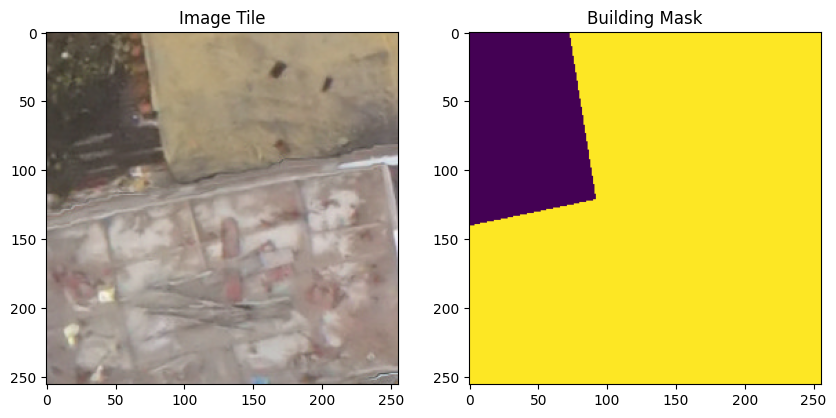

In [ ]:
tile = random.choice(os.listdir(image_dir))

img = np.load(os.path.join(image_dir, tile))
mask = np.load(os.path.join(mask_dir, tile))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img.transpose(1,2,0))
plt.title("Image Tile")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Building Mask")

plt.show()

# **SEGEMENTATION MODEL**

In [ ]:
class BuildingDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.files = os.listdir(image_dir)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]

        img = np.load(os.path.join(self.image_dir, file))
        mask = np.load(os.path.join(self.mask_dir, file))

        img = img.astype(np.float32)
        img = img / img.max()

        img = torch.tensor(img)
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [ ]:
dataset = BuildingDataset(image_dir, mask_dir)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Dataset size:", len(dataset))

Dataset size: 3798


## UNet Model

In [ ]:
class SimpleUNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,16,3,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(16,16,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,1,1)
        )

    def forward(self,x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [ ]:
#model = SimpleUNet().to(device)

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1
    intersection = (pred * target).sum()
    return 1 - ((2 * intersection + smooth) /
                (pred.sum() + target.sum() + smooth))
#loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
bce = nn.BCEWithLogitsLoss()

## TRAINING

In [ ]:
from torch.utils.data import random_split

dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [ ]:
save_path = "/content/drive/MyDrive/svamitva_project/models/best_unet.pth"

In [ ]:
#EXECUTION

import torch

epochs = 40
best_loss = float("inf")
patience = 5
counter = 0

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for i, (img, mask) in enumerate(train_loader):

        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)

        loss = bce(pred, mask) + dice_loss(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if i % 50 == 0:
            print(f"[Train] Epoch {epoch} Batch {i}/{len(train_loader)} Loss {loss.item():.4f}")

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    iou_total = 0
    dice_total = 0

    with torch.no_grad():
        for img, mask in val_loader:

            img = img.to(device)
            mask = mask.to(device)

            pred = model(img)

            loss = bce(pred, mask) + dice_loss(pred, mask)
            val_loss += loss.item()

            pred_bin = (torch.sigmoid(pred) > 0.7).float()

            intersection = (pred_bin * mask).sum()
            union = pred_bin.sum() + mask.sum()

            dice = (2 * intersection) / (union + 1e-8)
            iou = intersection / (union - intersection + 1e-8)

            dice_total += dice.item()
            iou_total += iou.item()

    val_loss /= len(val_loader)
    avg_dice = dice_total / len(val_loader)
    avg_iou = iou_total / len(val_loader)

    print(f"\nEpoch {epoch}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Dice:       {avg_dice:.4f}")
    print(f"IoU:        {avg_iou:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print("✅ Best model saved")
        counter = 0
    else:
        counter += 1
        print("No improvement:", counter, "/", patience)

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

[Train] Epoch 0 Batch 0/380 Loss 1.2572
[Train] Epoch 0 Batch 50/380 Loss 0.7446
[Train] Epoch 0 Batch 100/380 Loss 1.3698
[Train] Epoch 0 Batch 150/380 Loss 0.6822
[Train] Epoch 0 Batch 200/380 Loss 0.9829
[Train] Epoch 0 Batch 250/380 Loss 0.8392
[Train] Epoch 0 Batch 300/380 Loss 0.5374
[Train] Epoch 0 Batch 350/380 Loss 0.9206

Epoch 0
Train Loss: 0.8648
Val Loss:   0.7376
Dice:       0.7276
IoU:        0.5806
✅ Best model saved
[Train] Epoch 1 Batch 0/380 Loss 1.0374
[Train] Epoch 1 Batch 50/380 Loss 0.8005
[Train] Epoch 1 Batch 100/380 Loss 0.7795
[Train] Epoch 1 Batch 150/380 Loss 1.2503
[Train] Epoch 1 Batch 200/380 Loss 0.6422
[Train] Epoch 1 Batch 250/380 Loss 0.6765
[Train] Epoch 1 Batch 300/380 Loss 1.0279
[Train] Epoch 1 Batch 350/380 Loss 0.5673

Epoch 1
Train Loss: 0.8327
Val Loss:   0.9671
Dice:       0.7348
IoU:        0.5908
No improvement: 1 / 5
[Train] Epoch 2 Batch 0/380 Loss 0.6166
[Train] Epoch 2 Batch 50/380 Loss 0.7804
[Train] Epoch 2 Batch 100/380 Loss 0.7855


In [ ]:
model.load_state_dict(torch.load(save_path))
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## PREDICTION

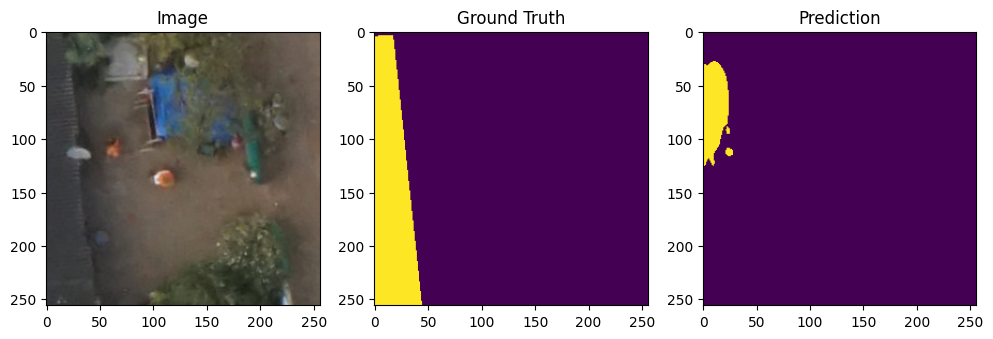

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import torch

tile = random.choice(os.listdir(image_dir))

img = np.load(os.path.join(image_dir, tile))
mask = np.load(os.path.join(mask_dir, tile))

img_tensor = torch.tensor(img / 255.0, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(img_tensor)
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float().cpu().numpy()[0,0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img.transpose(1,2,0))
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred)
plt.title("Prediction")

plt.show()

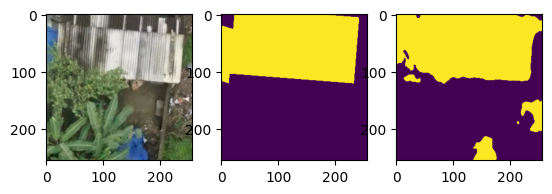

In [ ]:
img, mask = dataset[0]

with torch.no_grad():

    pred = model(img.unsqueeze(0).to(device))
    pred = torch.sigmoid(pred).cpu().numpy()[0,0]

plt.subplot(1,3,1)
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.imshow(mask[0])

plt.subplot(1,3,3)
plt.imshow(pred > 0.5)

## **EVALUATION METRIX**

In [ ]:
def compute_metrics(pred, mask):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection

    iou = intersection / (union + 1e-6)

    dice = (2 * intersection) / (pred.sum() + mask.sum() + 1e-6)

    return iou.item(), dice.item()

In [ ]:
img, mask = dataset[0]

img = img.unsqueeze(0).to(device)
mask = mask.unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(img)

iou, dice = compute_metrics(pred, mask)

print("IoU:", iou)
print("Dice:", dice)

IoU: 0.8236029148101807
Dice: 0.9032700061798096


## REFERENCE

In [ ]:
import numpy as np
import torch
import rasterio
from rasterio.windows import Window

tile_size = 256
stride = 256
batch_size = 8

def predict_full_image(img_path):

    with rasterio.open(img_path) as src:

        full_mask = np.zeros((src.height, src.width))

        batch_imgs = []
        batch_coords = []

        for y in range(0, src.height, stride):
            for x in range(0, src.width, stride):

                if x + tile_size > src.width or y + tile_size > src.height:
                    continue

                window = Window(x, y, tile_size, tile_size)
                image = src.read([1,2,3], window=window)

                if image.max() == 0:
                    continue

                # normalize
                img = image.astype(float)
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)

                batch_imgs.append(img)
                batch_coords.append((x, y))

                # 🔥 Run batch
                if len(batch_imgs) == batch_size:

                    batch_tensor = torch.tensor(batch_imgs, dtype=torch.float32).to(device)

                    with torch.no_grad():
                        preds = model(batch_tensor)
                        preds = torch.sigmoid(preds)
                        preds = (preds > 0.7).float().cpu().numpy()

                    for i in range(len(batch_coords)):
                        x_i, y_i = batch_coords[i]
                        full_mask[y_i:y_i+tile_size, x_i:x_i+tile_size] = preds[i,0]

                    batch_imgs = []
                    batch_coords = []

        # 🔥 process leftover tiles
        if len(batch_imgs) > 0:
            batch_tensor = torch.from_numpy(np.array(batch_imgs)).float().to(device)

            with torch.no_grad():
                preds = model(batch_tensor)
                preds = torch.sigmoid(preds)
                preds = (preds > 0.7).float().cpu().numpy()

            for i in range(len(batch_coords)):
                x_i, y_i = batch_coords[i]
                full_mask[y_i:y_i+tile_size, x_i:x_i+tile_size] = preds[i,0]

    return full_mask

In [ ]:
full_mask = predict_full_image(img_path)

/tmp/ipykernel_2989/416045451.py:41: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch_tensor = torch.tensor(batch_imgs, dtype=torch.float32).to(device)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.imshow(full_mask)
plt.title("Full Building Prediction")
plt.axis("off")